In [1]:
import pandas as pd

In [4]:
df = pd.read_csv(r'C:\Users\met00546\formation\Projet data analysis\uber_trips_dataset_50k.csv')

In [24]:
df.head()

,trip_id,driver_id,rider_id,city,pickup_lat,pickup_lng,drop_lat,drop_lng,distance_km,fare_amount,status,payment_method,pickup_time,drop_time,trip_duration_mins
0,1,8270,10683,San Francisco,37.170931,-77.586479,37.173652,-77.619934,2.97,10.71,Completed,Wallet,2023-01-01 00:00:00,2023-01-01 00:08:54.600,8.91
1,2,1860,44743,Boston,38.898127,-108.582977,38.937464,-108.558727,8.43,22.41,Completed,UPI,2023-01-01 00:01:00,2023-01-01 00:26:17.400,25.29
2,3,6390,75839,San Francisco,38.814571,-89.942603,38.821702,-89.896435,5.46,12.91,Completed,Cash,2023-01-01 00:02:00,2023-01-01 00:18:22.800,16.38
3,4,6191,22189,New York,37.295906,-75.328844,37.301375,-75.317488,6.61,15.70,Completed,Wallet,2023-01-01 00:03:00,2023-01-01 00:22:49.800,19.83
4,5,6734,61104,Seattle,38.972395,-121.482913,38.992088,-121.467904,10.50,19.15,Completed,Wallet,2023-01-01 00:04:00,2023-01-01 00:35:30.000,31.50


In [77]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   trip_id             50000 non-null  int64         
 1   driver_id           50000 non-null  int64         
 2   rider_id            50000 non-null  int64         
 3   city                50000 non-null  object        
 4   pickup_lat          50000 non-null  float64       
 5   pickup_lng          50000 non-null  float64       
 6   drop_lat            50000 non-null  float64       
 7   drop_lng            50000 non-null  float64       
 8   distance_km         50000 non-null  float64       
 9   fare_amount         50000 non-null  float64       
 10  status              50000 non-null  object        
 11  payment_method      50000 non-null  object        
 12  pickup_time         50000 non-null  datetime64[ns]
 13  drop_time           50000 non-null  datetime64

In [7]:
df['pickup_time']= pd.to_datetime(df['pickup_time'])

In [9]:
df['drop_time']= pd.to_datetime(df['drop_time'])

In [11]:
print(df['trip_id'].is_unique)

True


In [13]:
print(df['city'].unique())

['San Francisco' 'Boston' 'New York' 'Seattle' 'Chicago' 'Los Angeles']


In [14]:
print(df['status'].unique())

['Completed' 'No-Show' 'Cancelled']


In [15]:
print(df['payment_method'].unique())

['Wallet' 'UPI' 'Cash' 'Card']


In [46]:
df.describe()

C:\Users\met00546\AppData\Roaming\Python\Python312\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


,trip_id,driver_id,rider_id,pickup_lat,pickup_lng,drop_lat,drop_lng,distance_km,fare_amount,pickup_time,drop_time,trip_duration_mins,fare_per_km
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000,50000,50000.000000,5.000000e+04
mean,25000.500000,5493.954540,55040.994580,38.998664,-97.485552,38.998768,-97.485677,7.008070,15.976205,2023-01-18 08:39:30,2023-01-18 09:00:31.452636160,21.024211,inf
min,1.000000,1000.000000,10001.000000,37.000009,-121.999465,36.953365,-122.047124,0.000000,1.080000,2023-01-01 00:00:00,2023-01-01 00:08:54.600000,0.000000,1.289298e+00
25%,12500.750000,3232.750000,32539.000000,37.994428,-109.818282,37.998237,-109.817260,4.980000,11.510000,2023-01-09 16:19:45,2023-01-09 16:41:09,14.940000,1.982998e+00
50%,25000.500000,5497.000000,55164.000000,38.992589,-97.463042,38.994190,-97.464646,6.980000,15.430000,2023-01-18 08:39:30,2023-01-18 09:02:31.800000,20.940000,2.356178e+00
75%,37500.250000,7746.000000,77293.500000,39.999602,-85.190954,39.998849,-85.199652,9.000000,19.910000,2023-01-27 00:59:15,2023-01-27 01:21:38.849999872,27.000000,2.707368e+00
max,50000.000000,9998.000000,99998.000000,40.999937,-73.001961,41.047536,-72.963476,19.410000,50.670000,2023-02-04 17:19:00,2023-02-04 17:48:54.600000,58.230000,inf
std,14433.901067,2601.410798,25915.467105,1.155241,14.173744,1.155696,14.173735,2.946744,6.274406,NaN,NaN,8.840232,NaN


In [ ]:
# Calculate trip duration in minutes
df['trip_duration_mins'] = (df['drop_time'] - df['pickup_time']).dt.total_seconds() / 60

In [ ]:
df['fare_per_km'] = df['fare_amount'] / df['distance_km']


In [30]:
print(df[['fare_per_km','distance_km','fare_amount']].head())

   fare_per_km  distance_km  fare_amount
0     3.606061         2.97        10.71
1     2.658363         8.43        22.41
2     2.364469         5.46        12.91
3     2.375189         6.61        15.70
4     1.823810        10.50        19.15


In [42]:
cancellation_rate = (df[df['status'] == 'Cancelled'].count() / len(df)) * 100
print(f"Cancellation Rate: {cancellation_rate['status']:.2f}%")

Cancellation Rate: 9.97%


In [45]:
Completion_rate = df[df['status']== 'Completed'].count() /len(df)*100
print(f"Completion Rate: {Completion_rate['status']:.2f}%")

Completion Rate: 85.08%


In [56]:
df['Trips per City'] = (df.groupby('city')['trip_id'].transform('count'))/len(df)*100
print(df[['city','Trips per City']].drop_duplicates().head())   

            city  Trips per City
0  San Francisco          16.802
1         Boston          16.908
3       New York          16.494
4        Seattle          16.476
7        Chicago          16.690


In [62]:
df['trip_by_drivers'] = df.groupby('driver_id')['trip_id'].transform('count')
top_5_drivers = df[['driver_id', 'trip_by_drivers']].drop_duplicates().sort_values(by='trip_by_drivers', ascending=False).head(5)
print(top_5_drivers)

      driver_id  trip_by_drivers
4114       3925               16
6917       9998               16
4645       6599               16
4307       3415               15
300        5014               15


In [78]:
total_revenue = df[df['status'] == 'Completed']['fare_amount'].sum()
print(f"Total Revenue from Completed Trips: ${total_revenue:.2f}")

Total Revenue from Completed Trips: $679684.88


In [80]:
revenue_per_driver = (df[df['status']== 'Completed'].groupby('driver_id')['fare_amount'].sum().reset_index(name='total_revenue'))
print(revenue_per_driver
      .sort_values("total_revenue", ascending=False)
      .head())

      driver_id  total_revenue
5560       6599         262.25
27         1027         249.96
6951       8008         223.18
3118       4138         221.80
3318       4343         221.14


In [83]:
avg_trip_duration = df[df['status'] ==  'Completed']['trip_duration_mins'].mean()
print(f"Average Trip Duration for Completed Trips: {avg_trip_duration:.2f} minutes")

Average Trip Duration for Completed Trips: 21.03 minutes


In [95]:
# Combien de courses complétées ?
print(df["status"].value_counts())

# Combien de distance > 0 ?
print((df["distance_km"] > 0).sum())

# Combien de fare_amount > 0 ?
print((df["fare_amount"] > 0).sum())


status
Completed    42540
Cancelled     4984
No-Show       2476
Name: count, dtype: int64
49997
50000


In [96]:
# Courses complétées avec distance et fare valides
valid_trips = df[
    (df["status"] == "Completed") &
    (df["distance_km"].notna()) & (df["distance_km"] > 0) &
    (df["fare_amount"].notna()) & (df["fare_amount"] > 0)
]

print("Courses valides :", len(valid_trips))
print("Distance min/max :", valid_trips["distance_km"].min(), valid_trips["distance_km"].max())
print("Fare min/max :", valid_trips["fare_amount"].min(), valid_trips["fare_amount"].max())


Courses valides : 42538
Distance min/max : 0.01 18.6
Fare min/max : 1.08 48.2


In [105]:
corr_distance_fare = (valid_trips[["distance_km", "fare_amount"]].corr().iloc[0,1]*100).round(0)
print("Corrélation distance ↔ fare_amount :", corr_distance_fare, "%")


Corrélation distance ↔ fare_amount : 87.0 %


In [107]:
import matplotlib.pyplot as plt
import seaborn as sns

# Pour des graphes plus lisibles
sns.set(style="whitegrid")


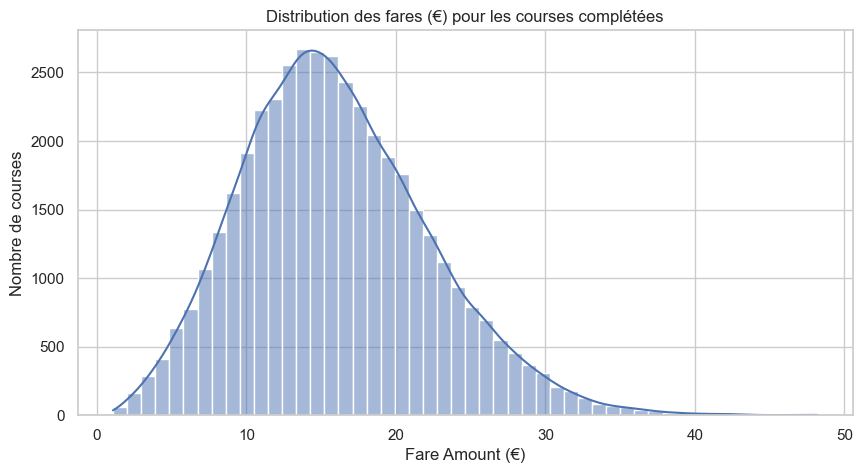

In [109]:
plt.figure(figsize=(10,5))
sns.histplot(valid_trips["fare_amount"], bins=50, kde=True)
plt.title("Distribution des fares (€) pour les courses complétées")
plt.xlabel("Fare Amount (€)")
plt.ylabel("Nombre de courses")
plt.show()


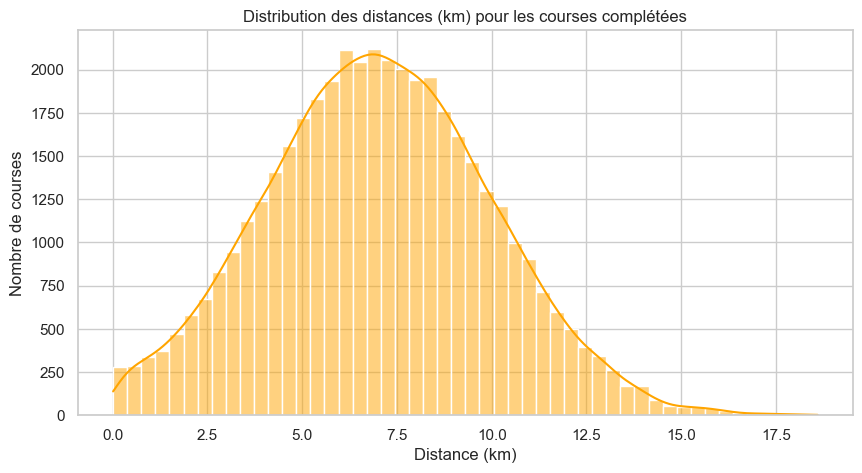

In [110]:
plt.figure(figsize=(10,5))
sns.histplot(valid_trips["distance_km"], bins=50, kde=True, color='orange')
plt.title("Distribution des distances (km) pour les courses complétées")
plt.xlabel("Distance (km)")
plt.ylabel("Nombre de courses")
plt.show()


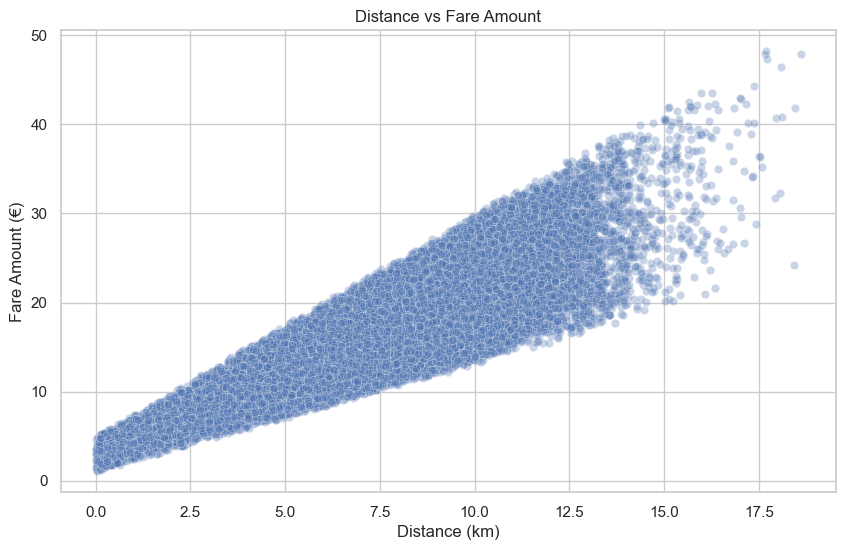

In [111]:
plt.figure(figsize=(10,6))
sns.scatterplot(x="distance_km", y="fare_amount", data=valid_trips, alpha=0.3)
plt.title("Distance vs Fare Amount")
plt.xlabel("Distance (km)")
plt.ylabel("Fare Amount (€)")
plt.show()


C:\Users\met00546\AppData\Local\Temp\ipykernel_30836\2085311756.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_5_drivers.index, y=top_5_drivers.values, palette="viridis")


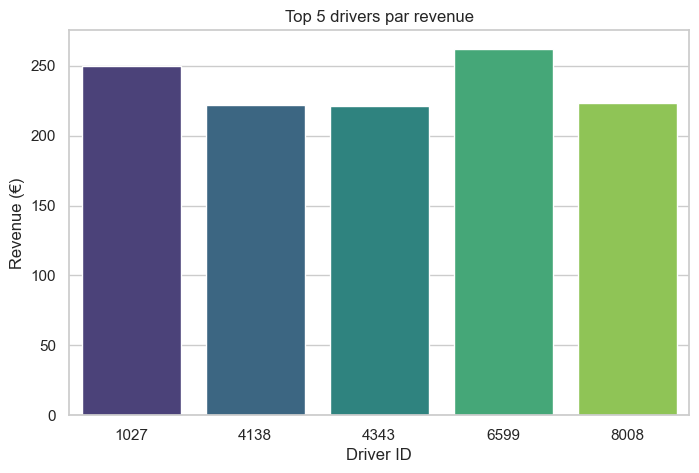

In [112]:
top_5_drivers = valid_trips.groupby("driver_id")["fare_amount"].sum().sort_values(ascending=False).head(5)

plt.figure(figsize=(8,5))
sns.barplot(x=top_5_drivers.index, y=top_5_drivers.values, palette="viridis")
plt.title("Top 5 drivers par revenue")
plt.xlabel("Driver ID")
plt.ylabel("Revenue (€)")
plt.show()
